### Integrantes:
- Valentina Giraldo Gaviria
- Sara Emanuelle Calderón

### **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y triple
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error

### **2. Carga de datos**

In [ ]:
data = pd.read_excel(r"Series de tiempo/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

(222, 4)


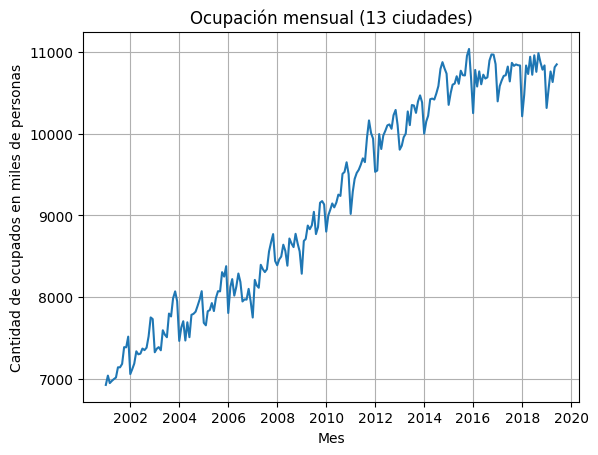

In [4]:
# Graficando los datos
plt.title("Ocupación mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Cantidad de ocupados en miles de personas")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

### **3. Encontrando los componentes de una serie de tiempo**

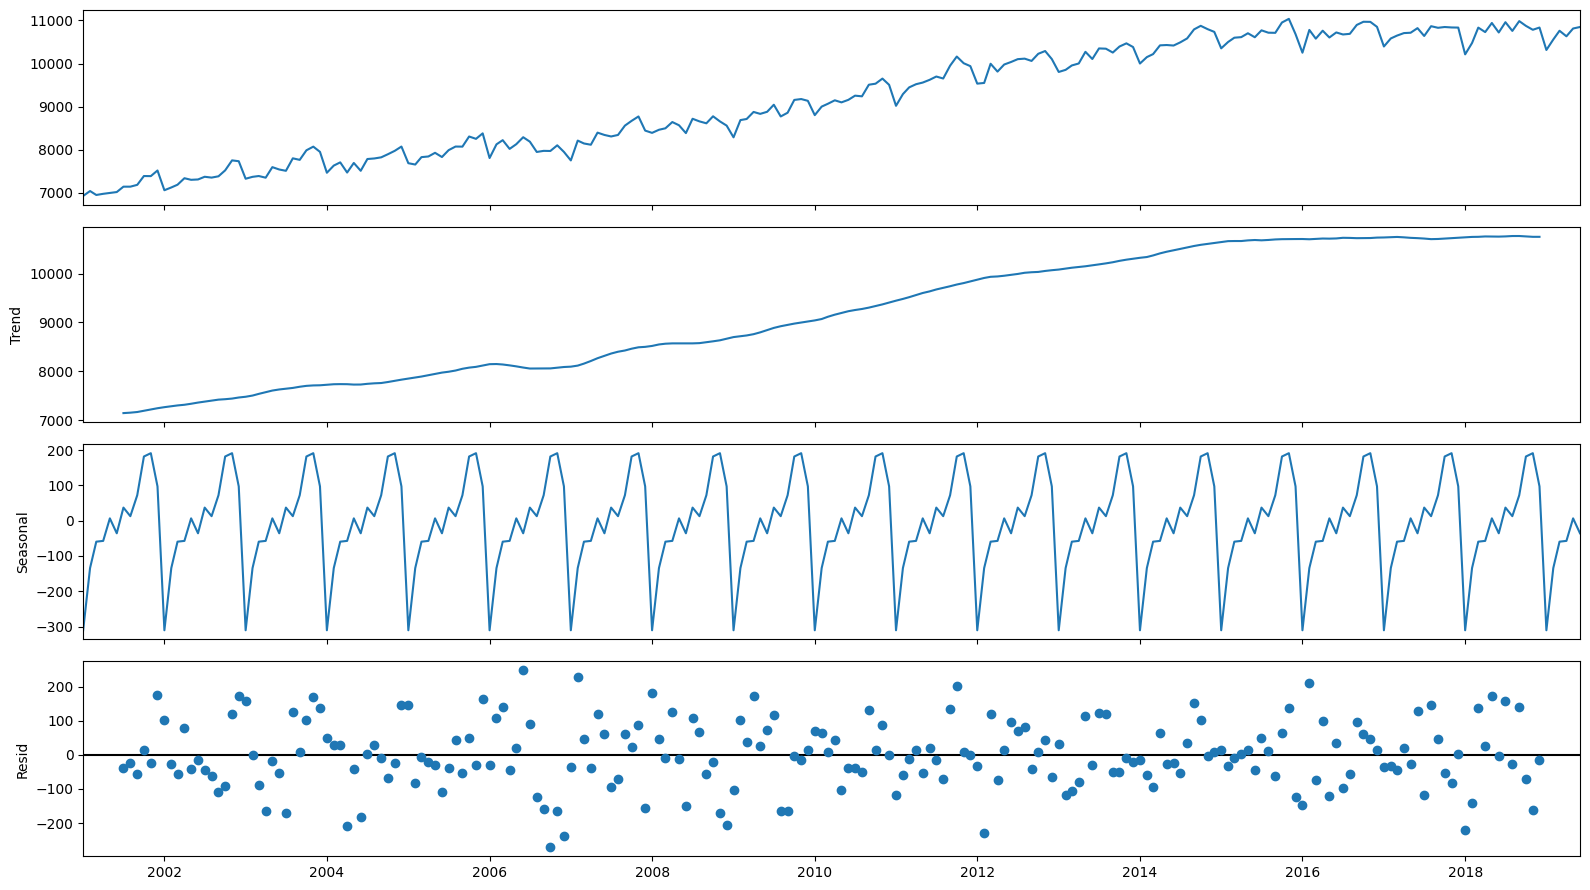

In [5]:
td_componentes = seasonal_decompose(data[["Ocupados"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

### **4. Pronosticando metodos de suavización**

Se utilizan los últimos 6 meses como conjunto de test, dado que, se necesita pronosticar 6 meses.

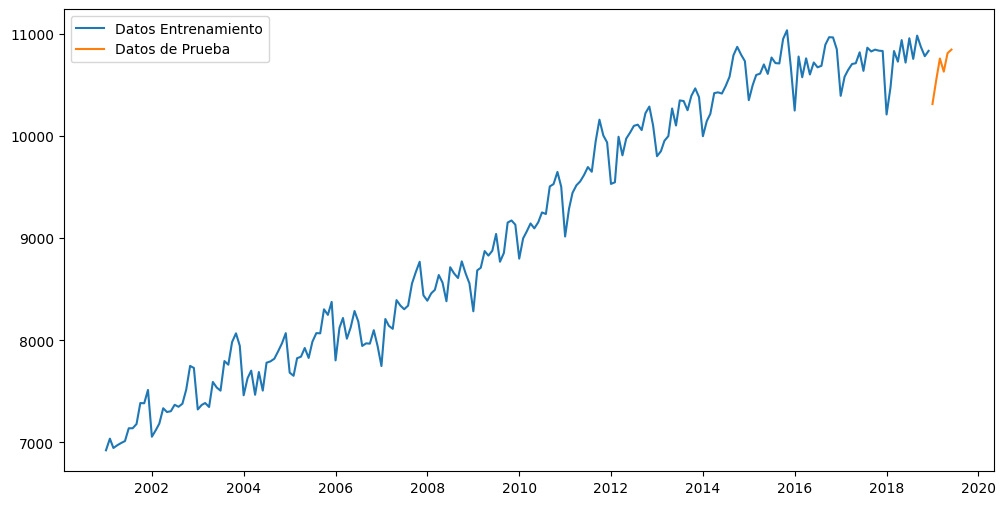

In [6]:
train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

plt.figure(figsize=(12,6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [7]:
train_td

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338


In [8]:
test_td

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


### **4.1 Promedio movil**

In [9]:
## Sin considerar el dato actual
ma_2= train_td.shift().rolling(2,min_periods=2).mean()
ma_3= train_td.shift().rolling(3,min_periods=2).mean()
ma_4= train_td.shift().rolling(4,min_periods=2).mean()
ma_5= train_td.shift().rolling(5,min_periods=2).mean()

In [10]:

def fore_ma(datos, w, h):
  # 1. Calcular el último promedio móvil (MA) usando los últimos 'w' datos de entrenamiento
  last_ma_value = datos["Ocupados"].tail(w).mean()
  
  # 2. Generar el índice de pronóstico (los próximos 'h' meses)
  last_index = datos.index[-1]
  forecast_index = pd.date_range(start=last_index, periods=h + 1, freq='MS')[1:]
  
  # 3. Crear el DataFrame de pronóstico con el valor MA extendido
  ma_forecast = pd.DataFrame(
      {'Ocupados': [last_ma_value] * h},
      index=forecast_index
  )
  return ma_forecast

In [11]:
ma_2_f= fore_ma(train_td,2,6)
ma_3_f= fore_ma(train_td,3,6)
ma_4_f= fore_ma(train_td,4,6)
ma_5_f= fore_ma(train_td,5,6)

In [12]:
test_td


,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


In [13]:
ma_2_f

,Ocupados
2019-01-01,10809.3485
2019-02-01,10809.3485
2019-03-01,10809.3485
2019-04-01,10809.3485
2019-05-01,10809.3485
2019-06-01,10809.3485


In [14]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f))

In [15]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5)

239.25694750745174 253.8272451008751 281.96402508354186 265.16596171611656


El mejor modelo de promedio móvil es el ma_2_f, este es el que se utilizará para comparar con otros modelos

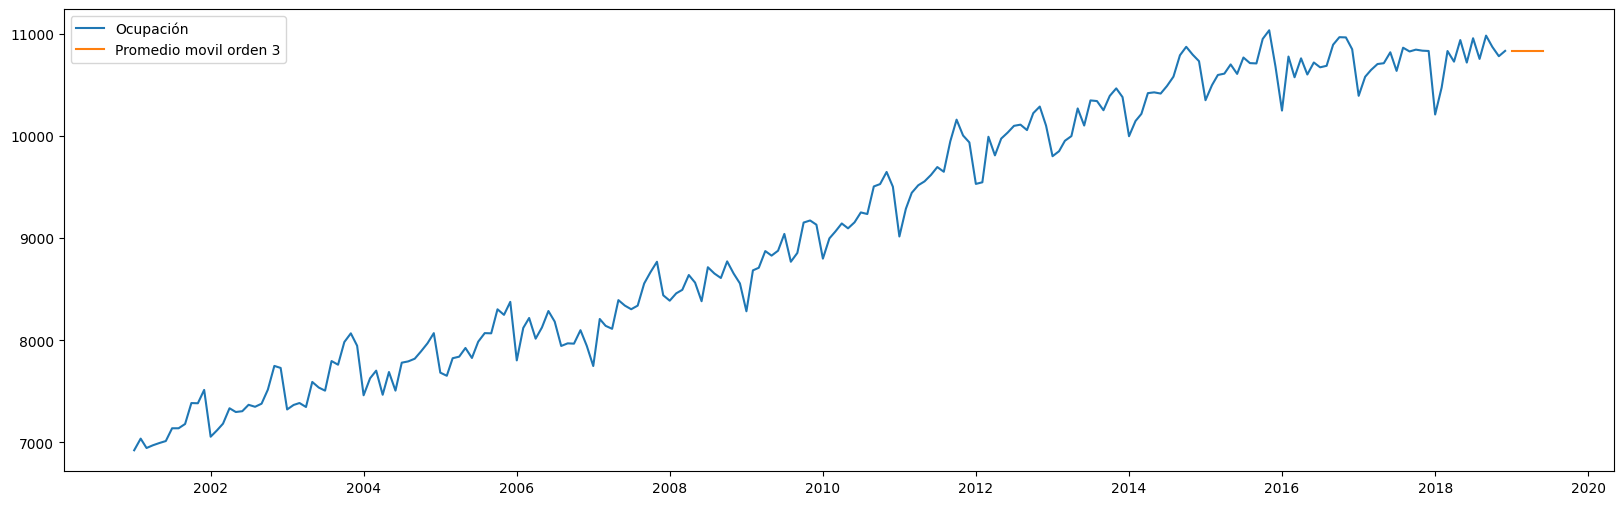

In [16]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Ocupación")
plt.plot(ma_3_f,label="Promedio movil orden 3")
plt.legend()
plt.show()

### **4.2 Suavizacion Exponencial Simple**

In [17]:

ets_model_1 = ETSModel(endog=train_td["Ocupados"], error="add", freq='MS') 
ets_result_1 = ets_model_1.fit()

point_forecast_1 = ets_result_1.forecast(6)

ci = ets_result_1.get_prediction(start=point_forecast_1.index[0],
                                end=point_forecast_1.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean

preds = pd.concat([limits, conf_forecast], axis=1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']

# Muestra de los pronósticos y cálculo del RMSE (los siguientes pasos son iguales)
print(preds)


            Point_forecast      lower_95      upper_95
2019-01-01    10830.738569  10476.461345  11185.015792
2019-02-01    10830.738569  10411.310139  11250.166999
2019-03-01    10830.738569  10354.999076  11306.478061
2019-04-01    10830.738569  10304.681612  11356.795526
2019-05-01    10830.738569  10258.773728  11402.703409
2019-06-01    10830.738569  10216.286263  11445.190874


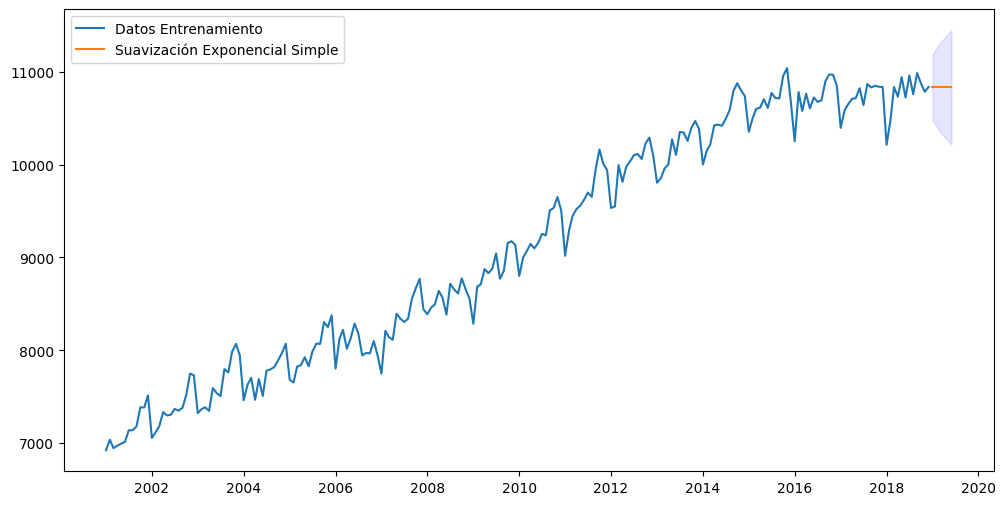

In [18]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [19]:
ets_result_1.alpha

np.float64(0.6337323614899885)

In [20]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast_1 ))
print(rmse)

253.63725759469287


### **4.3 Suavizacion Exponencial Lineal (Holt)**

In [21]:
# Build model.
ets_model_2 = ETSModel(endog=train_td["Ocupados"],error="add",trend="add", freq='MS')
ets_result_2 = ets_model_2.fit()

point_forecast_2=ets_result_2.forecast(6)

ci = ets_result_2.get_prediction(start = point_forecast_2.index[0],
                                end = point_forecast_2.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast      lower_95      upper_95
2019-01-01    10862.758891  10510.444658  11215.073124
2019-02-01    10879.826704  10472.720428  11286.932979
2019-03-01    10896.894516  10440.526883  11353.262150
2019-04-01    10913.962329  10412.222162  11415.702496
2019-05-01    10931.030142  10386.823344  11475.236940
2019-06-01    10948.097955  10363.687883  11532.508026


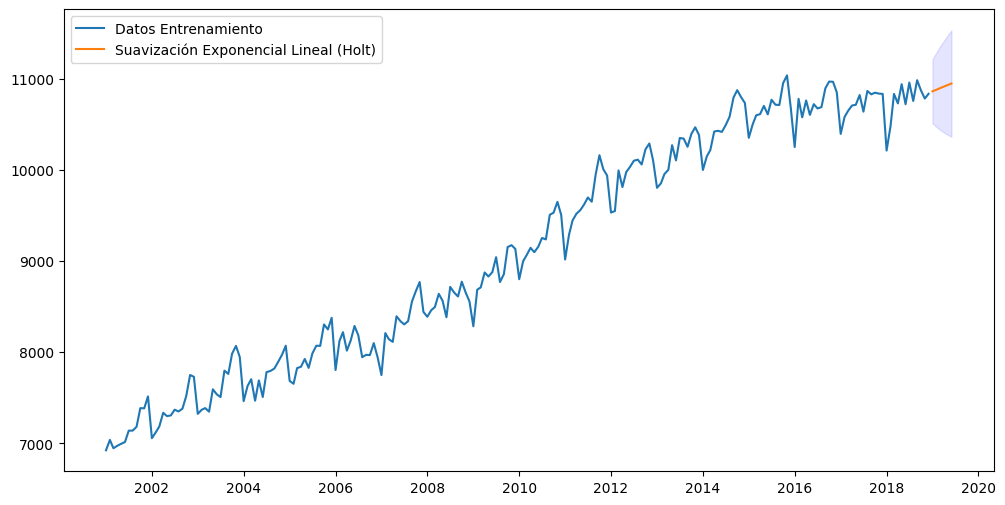

In [22]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [23]:
print(ets_result_2.alpha,ets_result_2.beta)

0.5725832891306255 0.00640491409667696


In [24]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

296.1552486103548


## **4.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [25]:
#Escoger el mejor modelo
seasonal_period = 12

# Combinaciones de modelos a probar
errors = ["add", "mul"]  # Aditivo, Multiplicativo
trends = ["add", "mul", "adddamped", "muldamped"]  # Aditivo, Multiplicativo, Aditivo Damped, Multiplicativo Damped
seasonals = [None, "add", "mul"]  # Ninguna, Aditiva, Multiplicativa

# Guardamos los resultados
results = {}

# Iterar sobre todas las combinaciones posibles
for error_type in errors:
    for trend_type in trends:
        for seasonal_type in seasonals:
            damped = "damped" in trend_type  # Si el nombre contiene "damped", se considera damped
            model_name = f"Error-{error_type} | Trend-{trend_type} | Seasonal-{seasonal_type if seasonal_type else 'None'}"
            
            # Crear el modelo ETS con todos los parámetros posibles
            model = ETSModel(
                endog=train_td["Ocupados"], 
                error=error_type, 
                trend=trend_type.replace('damped', ''),  # Eliminar "damped" del nombre para pasarlo correctamente
                seasonal=seasonal_type, 
                seasonal_periods=seasonal_period, 
                freq='MS',
                damped_trend=damped,  # Pasamos el parámetro damped
                initialization_method='estimated',  # Método de inicialización
                initial_level=None,  # Valor inicial de la serie
                initial_trend=None,  # Valor inicial de la tendencia
                initial_seasonal=None,  # Valor inicial de la estacionalidad
                bounds=None,  # No poner límites en los parámetros
                missing='none',  # No manejar valores faltantes de ninguna manera
            )
            
            # Ajustar el modelo
            result = model.fit()
            forecast = result.forecast(len(test_td))
            rmse = np.sqrt(mean_squared_error(test_td, forecast))
            results[model_name] = {'model': result, 'forecast': forecast, 'rmse': rmse}

# Comparar los resultados
print("\n--- Comparación de Modelos ---")
for model_name, result in results.items():
    print(f"{model_name} - RMSE: {result['rmse']:.4f}")

# Mejor modelo
print("\n--- Mejor Modelo ---")
best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"El mejor modelo es: {best_model} con RMSE de {results[best_model]['rmse']:.4f}")



--- Comparación de Modelos ---
Error-add | Trend-add | Seasonal-None - RMSE: 296.1552
Error-add | Trend-add | Seasonal-add - RMSE: 74.4086
Error-add | Trend-add | Seasonal-mul - RMSE: 59.6411
Error-add | Trend-mul | Seasonal-None - RMSE: 307.5021
Error-add | Trend-mul | Seasonal-add - RMSE: 66.4951
Error-add | Trend-mul | Seasonal-mul - RMSE: 59.4234
Error-add | Trend-adddamped | Seasonal-None - RMSE: 257.6303
Error-add | Trend-adddamped | Seasonal-add - RMSE: 86.7081
Error-add | Trend-adddamped | Seasonal-mul - RMSE: 110.8860
Error-add | Trend-muldamped | Seasonal-None - RMSE: 257.7706
Error-add | Trend-muldamped | Seasonal-add - RMSE: 79.3846
Error-add | Trend-muldamped | Seasonal-mul - RMSE: 109.8942
Error-mul | Trend-add | Seasonal-None - RMSE: 297.0369
Error-mul | Trend-add | Seasonal-add - RMSE: 72.7337
Error-mul | Trend-add | Seasonal-mul - RMSE: 61.9885
Error-mul | Trend-mul | Seasonal-None - RMSE: 317.4891
Error-mul | Trend-mul | Seasonal-add - RMSE: 67.7732
Error-mul | Trend

In [26]:

ets_model_3 = ETSModel(endog=train_td["Ocupados"], error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')
ets_result_3 = ets_model_3.fit()

point_forecast_3 = ets_result_3.forecast(6)

ci = ets_result_3.get_prediction(start = point_forecast_3.index[0],
                                end = point_forecast_3.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean

preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']

# Célula 161 (Modificada): Parámetros de suavización del nuevo modelo Multiplicativo


# Célula 162 (Modificada): RMSE del modelo Multiplicativo


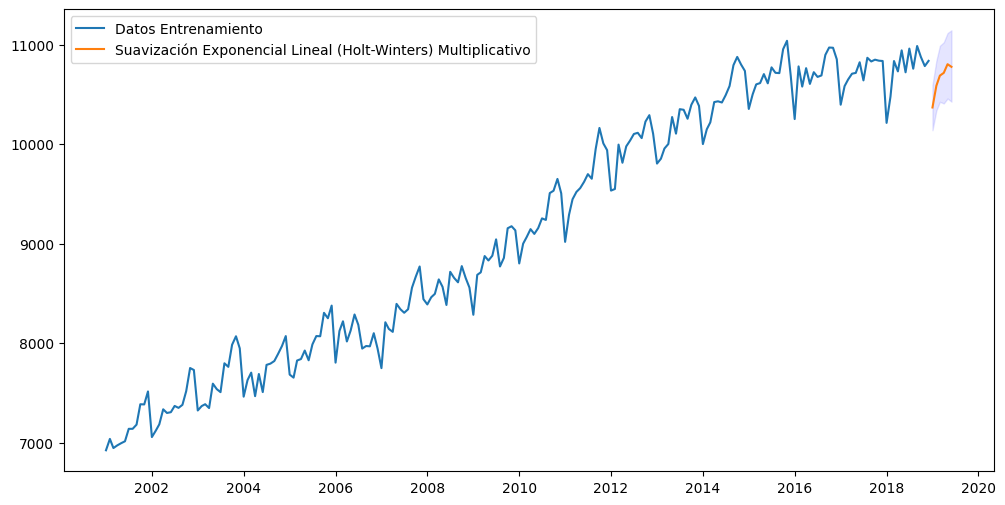

In [27]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [28]:
print("--- Parámetros de suavización del modelo Multiplicativo ---")
print(f"Alpha (Nivel): {ets_result_3.alpha}")
print(f"Beta (Tendencia): {ets_result_3.beta}")
print(f"Gamma (Estacionalidad): {ets_result_3.gamma}")

--- Parámetros de suavización del modelo Multiplicativo ---
Alpha (Nivel): 0.5253405498899031
Beta (Tendencia): 5.253405498899031e-05
Gamma (Estacionalidad): 4.746594501100969e-05


In [29]:
rmse_hw_mul= np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)


59.42340592249937


### Comparación Métricas de los modelos

In [30]:
# Crear DataFrame con los valores actuales
df_rmse = pd.DataFrame({
    "Modelo": [
        "Promedio móvil (MA-2)",
        "Suavización exponencial simple",
        "Suavización exponencial lineal (Holt)",
        "Suavización exponencial (Holt-Winters)",
    ],
    "RMSE": [
        rmse_ma_2,
        rmse,
        rmse_holt,
        rmse_hw_mul
    ]
})

# Ordenar por desempeño (menor RMSE primero)
df_rmse = df_rmse.sort_values("RMSE").reset_index(drop=True)

df_rmse

,Modelo,RMSE
0,Suavización exponencial (Holt-Winters),59.423406
1,Suavización exponencial simple,125.327978
2,Promedio móvil (MA-2),239.256948
3,Suavización exponencial lineal (Holt),296.155249


Mejor modelo el de **Suavización exponencial de Winters (Holt-Winters)**

Se obtienen los hiperparametros del mejor modelo y se reentrena el modelo con todos los datos y con los hiperparametros hallados.

In [31]:
## Se obtienen los hiperparametros

alpha_value = ets_result_3.alpha
beta_value = ets_result_3.beta
gamma_value = ets_result_3.gamma


In [32]:
final_model = ETSModel(endog=data["Ocupados"],error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')

In [33]:
final_model_fit = final_model.fit_constrained({
    'smoothing_level': alpha_value,
    'smoothing_trend': beta_value,
    'smoothing_seasonal': gamma_value
})

# Imprimir los parámetros ajustados (alpha, beta, gamma)
print("Alpha (final model):", final_model_fit.alpha)
print("Beta (final model):", final_model_fit.beta)
print("Gamma (final model):", final_model_fit.gamma)


Alpha (final model): 0.5253405498899031
Beta (final model): 5.253405498899031e-05
Gamma (final model): 4.746594501100969e-05


Se hacen las predicciones

In [34]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_final = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_final.columns = ['Pronóstico puntual', 'lower_95', 'upper_95']
print(preds_hw_final)

            Pronóstico puntual      lower_95      upper_95
2019-07-01        10915.692073  10702.732327  11129.671953
2019-08-01        10904.064814  10679.816579  11152.783115
2019-09-01        10997.716483  10742.616035  11265.948916
2019-10-01        11140.582549  10831.788920  11446.818877
2019-11-01        11165.789038  10847.284413  11472.409749
2019-12-01        11070.065860  10730.690008  11400.632822


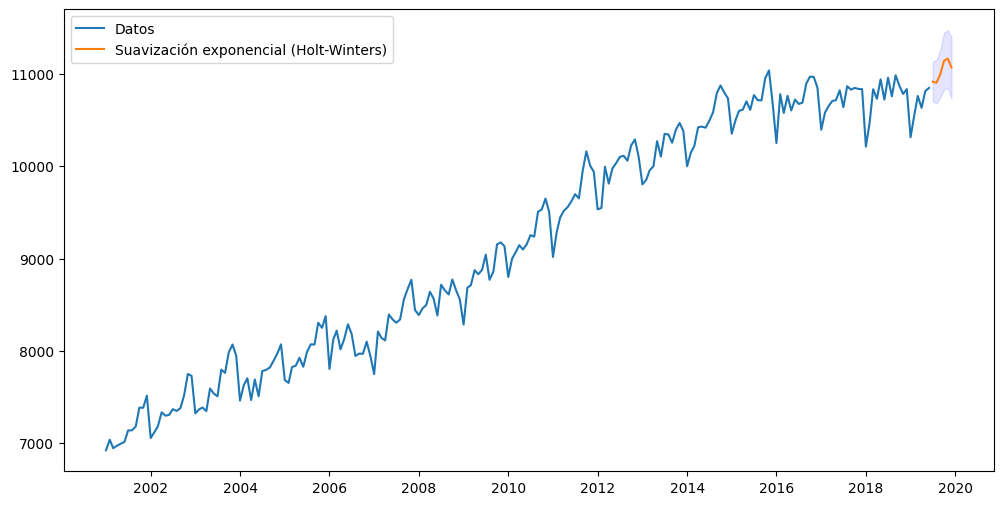

In [35]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["Ocupados"],label="Datos")
plt.plot(preds_hw_final['Pronóstico puntual'],label="Suavización exponencial (Holt-Winters)")
plt.fill_between(preds_hw_final.index ,preds_hw_final['lower_95'], preds_hw_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()